## A/B - тестирование


Внутри увидите пример как формируются результаты по аб-тестированию. Прочтите сначала его, затем приступайте к выполнению задания.

В папке присутствует файл ab_test_ensembles.csv , который содержит реальные данные ab теста. Вам необходимо провести стандартный пайплайн, начав с ознакомления данных до вывода отчета. Условие гипотезы такое же как и в примере, нам необходимо нашим новым вариантом увеличить коэффициент конверсии на 2%, коэффициенты конверсии одинаковы с файлом из примера (плюс/минус) поэтому с этим проблем быть не должно. Условия гипотез теже.

В A/B тесте было два варианта работы сервиса - standard и svm_ensemble_v_1_22, где работала модель классификации пользователей.

Ответьте на 2 вопроса:

1. Стоит ли нам оставить старый вариант работы или заменить на вариант svm_ensemble_v_1_22 (используем всю выборку 200к+ записей)
2. Так же посчитайте вывод для типа пользователей (user_type) стоит ли для новых/старых пользователей (new/registered user) оставить старый / новый вариант работы (разделяем всю выборку 200к+ записей на группы)

Также необходимо провести небольшое EDA по представленному датасету, нарисовать два графика на ваш вкус.

---

**Баллы могут быть снижены** за качество кода - старайтесь чтобы код был максимально лаконичным. Названия переменных (если они используются) должны отражать максимальную ее сущность.

**Комментарии по сдаче практического задания**:
1. Залить в репу на github в папку module_2/ab_test_inference
2. Ссылку на репо отправлять мне на почту alexadevv@gmail.com не позднее дедлайна.
3. Тема письма: Домашнее задание по модулю 2 <Фамилия Имя>
4. После дедлайна, неотправленные на почту задания, оцениваются максимум в 7 баллов.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import statsmodels.stats.api as sms
import seaborn as sns
from scipy import stats
from statsmodels.stats import proportion
from statsmodels.stats import power as smp
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
import warnings
warnings.filterwarnings('ignore')

In [54]:
df = pd.read_csv('ab_test_ensembles.csv')
df.head(10)

,user_id,timestamp,group,variants,converted,location,age_group,user_type
0,9109b0dc-d393-497f-8d63-ba9a25dd16b4,2022-05-21 22:11:48.556739,control,standard,0,United Kingdom,18-25,registered_user
1,2430c3d2-f75b-4b31-8271-51b6a76c2652,2022-05-12 08:01:45.159739,control,standard,0,United Kingdom,42-49,registered_user
2,44788c4e-8dd2-4fad-b986-75e76f4adb64,2022-05-11 16:55:06.154213,treatment,svm_ensemble_v_1_22,0,United Kingdom,26-33,new_user
3,4699a417-506d-41b8-a354-6af6ad576963,2022-05-08 18:28:03.143765,treatment,svm_ensemble_v_1_22,0,United Kingdom,42-49,registered_user
4,304b0d28-bcdf-401a-9dff-66230d3ba0bc,2022-05-21 01:52:26.210827,control,standard,1,United Kingdom,42-49,registered_user
5,426f77eb-8739-43b6-999c-aecd14d9f346,2022-05-10 15:20:49.083499,control,standard,0,United Kingdom,42-49,registered_user
6,aa9d93c5-a18f-444a-a522-7e7145835362,2022-05-19 03:26:46.940749,treatment,svm_ensemble_v_1_22,1,United Kingdom,26-33,registered_user
7,de214e30-9b8d-44cf-87b1-16917f3e1c89,2022-05-17 01:48:29.539573,control,standard,0,United Kingdom,18-25,registered_user
8,070f398e-e6bf-43e7-88bb-37eff2cb9212,2022-05-04 17:58:08.979471,treatment,svm_ensemble_v_1_22,1,United Kingdom,18-25,new_user
9,9cff0b7e-d42b-4508-9fbe-a4e74f7f29c5,2022-05-15 18:11:06.610965,treatment,svm_ensemble_v_1_22,1,United Kingdom,26-33,new_user


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    294478 non-null  object
 1   timestamp  294478 non-null  object
 2   group      294478 non-null  object
 3   variants   294478 non-null  object
 4   converted  294478 non-null  int64 
 5   location   294478 non-null  object
 6   age_group  294478 non-null  object
 7   user_type  294478 non-null  object
dtypes: int64(1), object(7)
memory usage: 18.0+ MB


In [56]:
df.shape

(294478, 8)

In [57]:
df.isnull().sum()

user_id      0
timestamp    0
group        0
variants     0
converted    0
location     0
age_group    0
user_type    0
dtype: int64

In [58]:
pd.crosstab(df['group'], df['variants']) #так же как и в примере необходимо убедиться что контрольная группа и испытуемая видят старую и новую страницу

variants,standard,svm_ensemble_v_1_22
group,,
control,145274,1928
treatment,1965,145311


In [72]:
baseline_conversion = 0.13  # текущая конверсия 13%
expected_conversion = 0.15  # ожидаемая конверсия 15%
alpha = 0.05  # уровень значимости
power = 0.8   # мощность теста 80%
ratio = 1     # соотношение групп 1:1


effect_size = sms.proportion_effectsize(baseline_conversion, expected_conversion)
print(f"Размер эффекта: {effect_size:.4f}") # как мы видим наш эффект размерности очень мал и конверсия в тестовой группе ниже чем в контрольной 



Размер эффекта: -0.0577


In [74]:
for column in ['user_type']: # тут мы прверяем баланс распределения категориальной переменной user_type
    print(f"Распределение по '{column}':")
    cross_tab = pd.crosstab(df[column], df['group'], normalize='columns') * 100
    print(cross_tab.round(2))
    chi2, p_val, _, _ = stats.chi2_contingency(pd.crosstab(df[column], df['group']))

Распределение по 'user_type':
group            control  treatment
user_type                          
new_user            50.1       49.9
registered_user     49.9       50.1


In [60]:
# Далее посчитаем необходимое количество наблюдений
required_n = smp.NormalIndPower().solve_power(effect_size = effect_size ,power = power,alpha = alpha,ratio = ratio)
required_n = ceil(required_n)
print(f"Для каждой группы необходимо не меньше {required_n:,} наблюдений")
print(f"Общий минимальный размер выборки: {required_n*2:,} наблюдений")

Для каждой группы необходимо не меньше 4,720 наблюдений
Общий минимальный размер выборки: 9,440 наблюдений


In [67]:
# Разделяем данные на группы
control_data = df[df['group'] == 'control'].sample(n = required_n, random_state=42)
treatment_data = df[df['group'] == 'treatment'].sample(n = required_n, random_state=42)

In [63]:
ab_df = pd.concat([control_data, treatment_data], axis = 0)
ab_df.reset_index(drop=True, inplace=True)
ab_df.head(10)

,user_id,timestamp,group,variants,converted,location,age_group,user_type
0,bcf8452b-3056-4d45-994f-5f286fd9869a,2022-05-18 04:44:18.590293,control,standard,0,United Kingdom,42-49,new_user
1,3c827a98-0868-4ce5-ac31-8195e243af37,2022-05-14 05:22:43.771772,control,standard,0,United Kingdom,50-57,new_user
2,71c72bb9-13d9-4755-b398-b2c5d8b1c4d6,2022-05-23 08:52:53.050325,control,standard,0,United Kingdom,34-41,new_user
3,654ee878-b0c5-4223-b9fb-995ca3d2eaf1,2022-05-07 23:27:09.109877,control,standard,0,United Kingdom,26-33,registered_user
4,1e044366-7e86-4d92-bba7-3afaa6f887f8,2022-05-20 14:26:10.133979,control,standard,0,United Kingdom,42-49,new_user
5,b110d9f7-4dbf-4ad4-a3e2-63c4ed67b775,2022-05-08 22:55:45.560800,control,standard,1,United Kingdom,34-41,new_user
6,ef2d7a79-1bfd-4b16-a223-fb0c0c8cb7ff,2022-05-11 01:15:34.573185,control,standard,0,United Kingdom,58+,registered_user
7,8803a8d0-96e6-4c9c-9838-43f5f6034dfe,2022-05-10 06:28:11.592374,control,standard,0,United Kingdom,50-57,registered_user
8,9e8171a4-1d1c-4f87-91a0-60f84878e466,2022-05-18 06:21:51.862515,control,standard,0,United Kingdom,18-25,new_user
9,d28cd717-d11a-4d82-a5e4-26b6c86243a5,2022-05-06 01:15:56.520433,control,standard,0,United Kingdom,26-33,registered_user


In [64]:
ab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9440 entries, 0 to 9439
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    9440 non-null   object
 1   timestamp  9440 non-null   object
 2   group      9440 non-null   object
 3   variants   9440 non-null   object
 4   converted  9440 non-null   int64 
 5   location   9440 non-null   object
 6   age_group  9440 non-null   object
 7   user_type  9440 non-null   object
dtypes: int64(1), object(7)
memory usage: 590.1+ KB


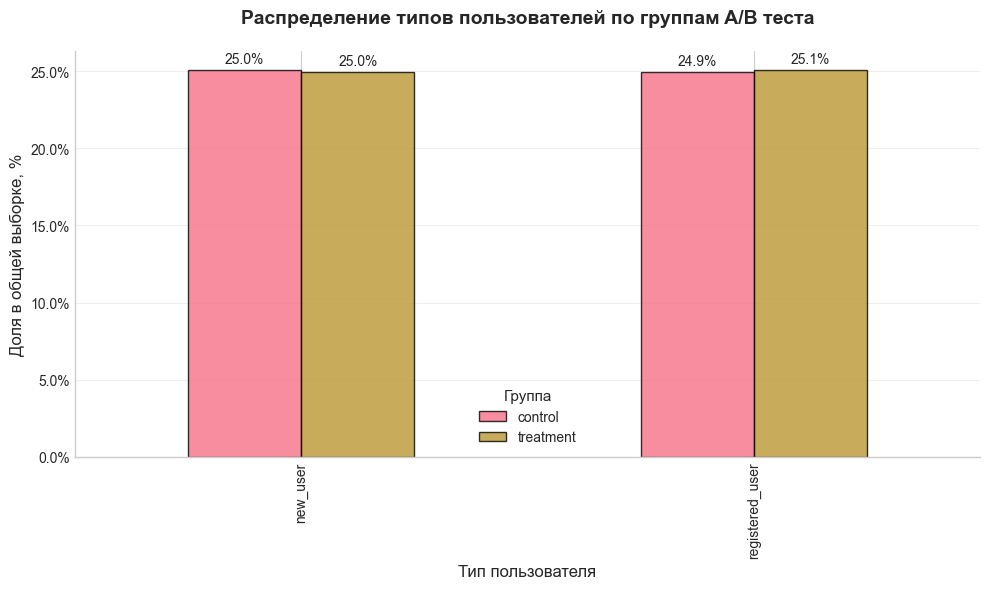

In [103]:
plt.style.use('seaborn-v0_8-whitegrid') # график распределения типов пользователей по группам A/B теста
sns.set_palette("husl")

user_type_dist = pd.crosstab(df['user_type'], df['group'], normalize='all') * 100
fig, ax = plt.subplots(figsize=(10, 6))
user_type_dist.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.8)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, axis='y', alpha=0.3)
ax.set_title('Распределение типов пользователей по группам A/B теста', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Тип пользователя', fontsize=12)
ax.set_ylabel('Доля в общей выборке, %', fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(title='Группа', title_fontsize=11, frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

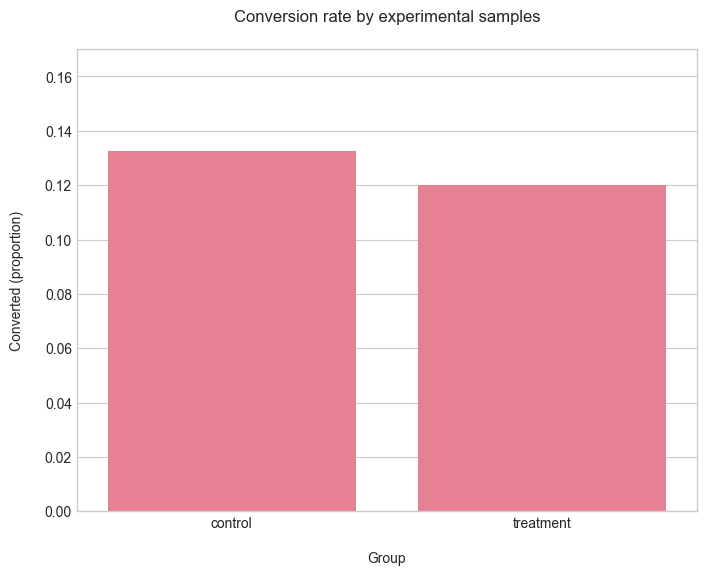

In [105]:
plt.figure(figsize=(8,6));
sns.barplot(x=ab_df['group'], y=ab_df['converted'], ci=False);
plt.ylim(0, 0.17);
plt.title('Conversion rate by experimental samples', pad=20)
plt.xlabel('Group', labelpad=15);
plt.ylabel('Converted (proportion)', labelpad=15);

In [104]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

control_results = ab_df[ab_df['group'] == 'control']['converted']
treatment_results = ab_df[ab_df['group'] == 'treatment']['converted']

n_con = control_results.count()
n_treat = treatment_results.count()
successes = [control_results.sum(), treatment_results.sum()]
nobs = [n_con, n_treat]

z_stat, pval = proportions_ztest(successes, nobs=nobs)
(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(successes, nobs=nobs, alpha=0.05)

print(f'Z-statistic: {z_stat:.2f}')
print(f'p-value: {pval:.3f}')
print(f'CI 95% for control group: [{lower_con:.3f}, {upper_con:.3f}]')
print(f'CI 95% for treatment group: [{lower_treat:.3f}, {upper_treat:.3f}]')

Z-statistic: 1.83
p-value: 0.067
CI 95% for control group: [0.123, 0.142]
CI 95% for treatment group: [0.111, 0.129]


In [80]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

new_users = df[df['user_type'] == 'new_user']

new_control = new_users[new_users['group'] == 'control']['converted']
new_treatment = new_users[new_users['group'] == 'treatment']['converted']

n_new_con = new_control.count()
n_new_treat = new_treatment.count()
successes_new = [new_control.sum(), new_treatment.sum()]

p_new_con = successes_new[0] / n_new_con
p_new_treat = successes_new[1] / n_new_treat


z_stat_new, pval_new = proportions_ztest(successes_new, nobs=[n_new_con, n_new_treat]) # это новый Z-тест для new_user

print(f"Контроль: {successes_new[0]}/{n_new_con} = {p_new_con:.3%}")
print(f"Тест: {successes_new[1]}/{n_new_treat} = {p_new_treat:.3%}")
print(f"Разница: {p_new_treat - p_new_con:.3%}")
print(f"p-value: {pval_new:.4f}")

if pval_new < 0.05:
    if p_new_treat > p_new_con:
        print("Для Новых пользователей: Внедрять новый вариант")
    else:
        print("Для Новых пользователей: Оставить старый вариант")
else:
    print("Для Новых пользователей: различий нет, оставить текущий вариант")


reg_users = df[df['user_type'] == 'registered_user']

reg_control = reg_users[reg_users['group'] == 'control']['converted']
reg_treatment = reg_users[reg_users['group'] == 'treatment']['converted']

n_reg_con = reg_control.count()
n_reg_treat = reg_treatment.count()
successes_reg = [reg_control.sum(), reg_treatment.sum()]

p_reg_con = successes_reg[0] / n_reg_con
p_reg_treat = successes_reg[1] / n_reg_treat


z_stat_reg, pval_reg = proportions_ztest(successes_reg, nobs=[n_reg_con, n_reg_treat]) # Z-тест для зарегистрированных пользователей

print(f"Контроль: {successes_reg[0]}/{n_reg_con} = {p_reg_con:.3%}")
print(f"Тест: {successes_reg[1]}/{n_reg_treat} = {p_reg_treat:.3%}")
print(f"Разница: {p_reg_treat - p_reg_con:.3%}")
print(f"p-value: {pval_reg:.4f}")

if pval_reg < 0.05:
    if p_reg_treat > p_reg_con:
        print("Для Зарегистрированных: Внедрять новый вариант")
    else:
        print("Для Зарегистрированных: Оставить старый вариант")
else:
    print("Для Зарегистрированных: различий нет, оставить текущий вариант")



Контроль: 8905/73750 = 12.075%
Тест: 8639/73488 = 11.756%
Разница: -0.319%
p-value: 0.0589
Для НОВЫХ пользователей: различий нет, оставить текущий вариант
Контроль: 8818/73452 = 12.005%
Тест: 8875/73788 = 12.028%
Разница: 0.023%
p-value: 0.8940
Для ЗАРЕГИСТРИРОВАННЫХ: различий нет, оставить текущий вариант


 НЕ внедрять новый вариант
   - Для всех пользователей: p=0.067 > 0.05
   - Для новых пользователей: нет значимых различий
   - Для зарегистрированных: нет значимых различий